# 🎯 DSO3 — Système de Recommandation
## MediFollow - Modélisation Machine Learning

**Objectif** : Recommander des actions de suivi personnalisées aux patients.

**Modèles** : Filtrage Collaboratif, Content-Based, Hybride

---

## 📦 Imports & Configuration

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import os, time, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATASETS_DIR = os.getcwd() # Set DATASETS_DIR to the current working directory '/content/'
print('✅ Imports OK')

✅ Imports OK


---
## 📁 Étape 1 : Datasets Before Cleaning

In [51]:
patients_raw = pd.read_csv(os.path.join(DATASETS_DIR, 'patients.csv'))
items_raw = pd.read_csv(os.path.join(DATASETS_DIR, 'items.csv'))
interactions_raw = pd.read_csv(os.path.join(DATASETS_DIR, 'interactions.csv'))

print(f"Patients     : {patients_raw.shape} — NaN: {patients_raw.isnull().sum().sum()}, Doublons ID: {patients_raw.duplicated(subset='patient_id').sum()}")
print(f"Items        : {items_raw.shape}")
print(f"Interactions : {interactions_raw.shape} — NaN: {interactions_raw.isnull().sum().sum()}, Doublons: {interactions_raw.duplicated().sum()}")
print(f"Ratings hors [1,5]: {((interactions_raw['rating'] < 1) | (interactions_raw['rating'] > 5)).sum()}")

Patients     : (1000, 8) — NaN: 0, Doublons ID: 0
Items        : (6, 6)
Interactions : (5000, 5) — NaN: 0, Doublons: 0
Ratings hors [1,5]: 0


In [52]:
patients_raw.head(10)

,patient_id,age,sexe,niveau_risque,nb_comorbidites,type_pathologie,observance,score_autonomie
0,0,67,F,moyen,2.0,orthopedique,0.695371,10.0
1,1,37,F,moyen,3.0,orthopedique,0.711646,8.0
2,2,25,F,moyen,2.0,orthopedique,0.313394,4.0
3,3,61,M,moyen,0.0,respiratoire,0.332424,1.0
4,4,71,M,faible,0.0,cardiaque,0.619607,2.0
5,5,30,M,faible,0.0,cardiaque,0.414621,8.0
6,6,45,M,eleve,4.0,neurologique,0.679520,10.0
7,7,40,F,faible,2.0,cardiaque,0.631311,8.0
8,8,59,F,faible,4.0,cardiaque,0.651456,5.0
9,9,75,F,eleve,0.0,diabete,0.481473,6.0


In [53]:
items_raw.head(10)

,nom,categorie,frequence_recommandee,niveau_difficulte,pathologie_cible,item_id
0,Bilan qualite de vie,questionnaire,bi-hebdomadaire,moyen,neurologique,0
1,Suivi symptomes,questionnaire,hebdomadaire,difficile,respiratoire,1
2,Prise temperature,medicament,mensuel,difficile,general,2
3,Auto-evaluation humeur,questionnaire,hebdomadaire,facile,orthopedique,3
4,Visite pneumologue,consultation,mensuel,difficile,respiratoire,4
5,Module education diabete,education,bi-hebdomadaire,moyen,diabete,5


In [54]:
interactions_raw.head(10)

,patient_id,item_id,rating,completed,nb_fois_realise
0,981,2,2.706364,1,6
1,245,2,4.897599,0,11
2,828,4,1.431182,0,5
3,975,0,1.827219,1,3
4,383,5,2.365250,0,2
5,41,5,1.914288,1,4
6,284,1,3.501768,0,18
7,979,1,1.158203,1,7
8,987,2,1.709747,0,4
9,922,4,2.173389,0,12


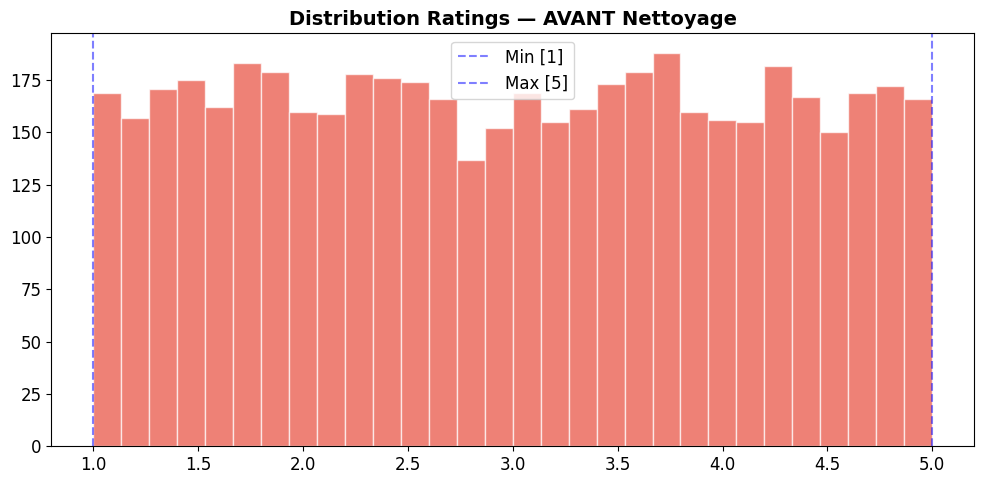

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(interactions_raw['rating'].dropna(), bins=30, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(1, color='blue', linestyle='--', alpha=0.5, label='Min [1]')
ax.axvline(5, color='blue', linestyle='--', alpha=0.5, label='Max [5]')
ax.set_title('Distribution Ratings — AVANT Nettoyage', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🧹 Étape 2 : Datasets After Cleaning

In [56]:
# NOTE: Assuming 'patients.csv', 'items.csv', 'interactions.csv' are the cleaned versions as no separate 'after_cleaning' files were found.
# This means 'patients' will currently load the same data as 'patients_raw' until an explicit cleaning step or different files are provided.
patients = pd.read_csv(os.path.join(DATASETS_DIR, 'patients.csv'))
items = pd.read_csv(os.path.join(DATASETS_DIR, 'items.csv'))
interactions = pd.read_csv(os.path.join(DATASETS_DIR, 'interactions.csv'))

print(f"Patients     : {patients.shape} — NaN: {patients.isnull().sum().sum()}")
print(f"Items        : {items.shape}")
print(f"Interactions : {interactions.shape} — NaN: {interactions.isnull().sum().sum()}")
print(f"Ratings dans [1,5]: {interactions['rating'].between(1, 5).all()}")

Patients     : (1000, 8) — NaN: 0
Items        : (6, 6)
Interactions : (5000, 5) — NaN: 0
Ratings dans [1,5]: True


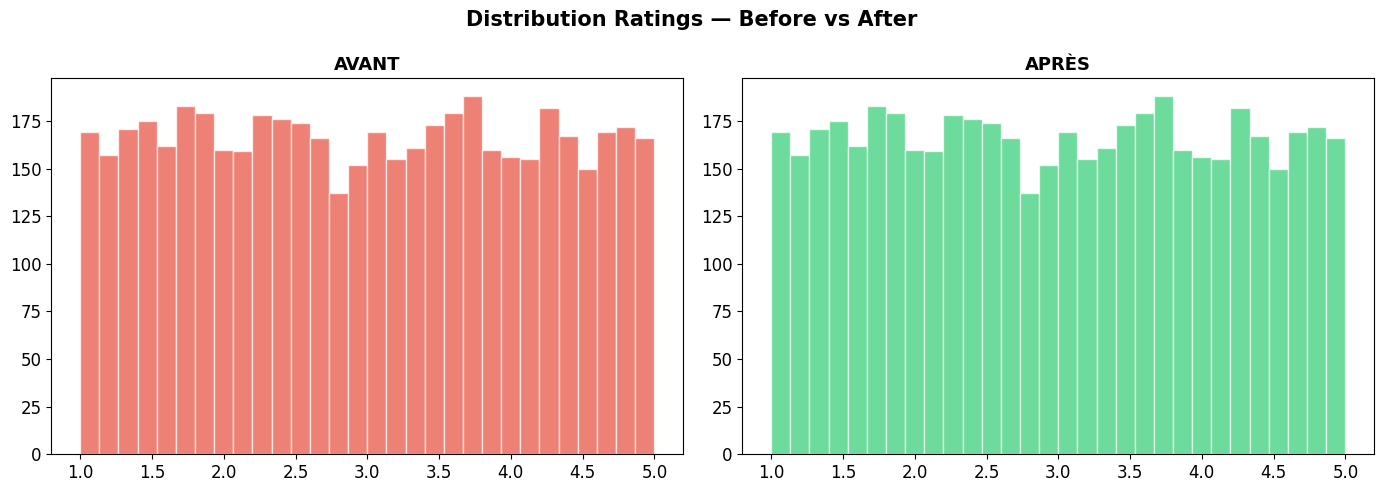

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(interactions_raw['rating'].dropna(), bins=30, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('AVANT', fontsize=13, fontweight='bold')
axes[1].hist(interactions['rating'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('APRÈS', fontsize=13, fontweight='bold')
plt.suptitle('Distribution Ratings — Before vs After', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Étape 3 : Processing (Matrice User-Item + Split)

Matrice User-Item : (1000, 6)
Sparsité : 44.23%
Rating moyen : 2.99


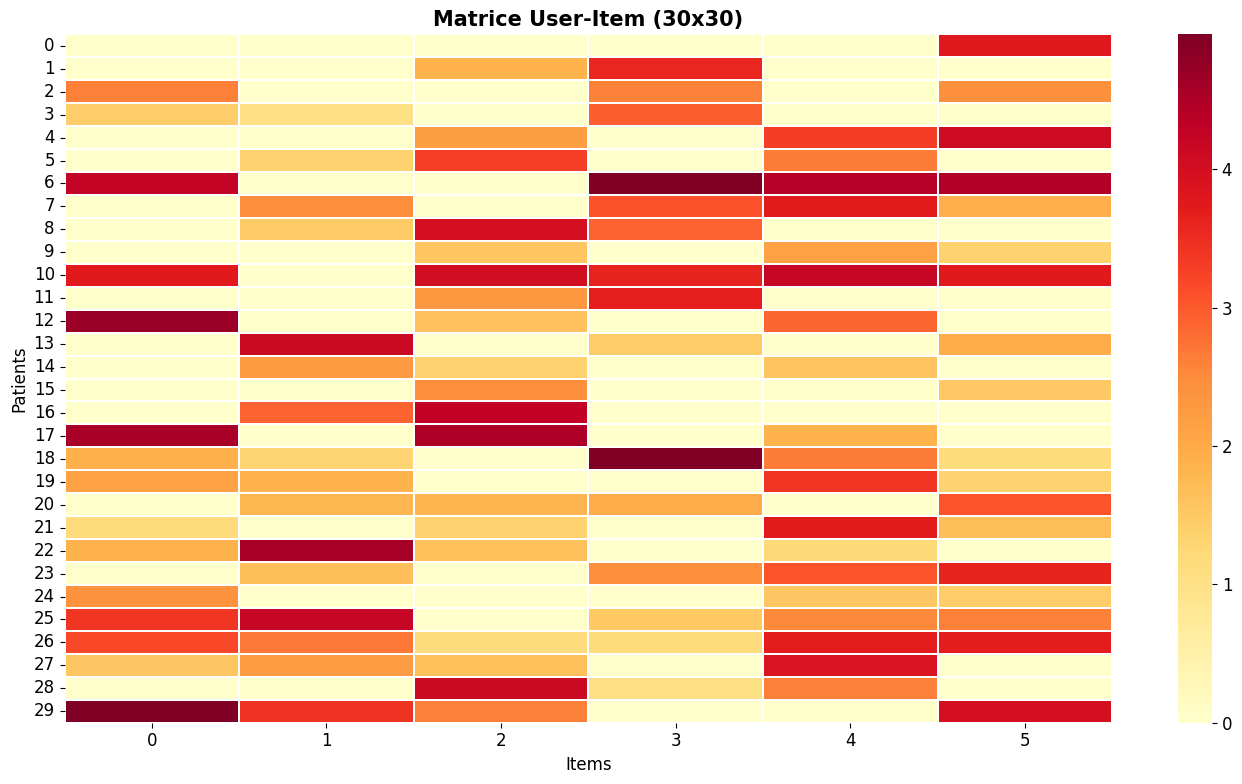

In [58]:
n_patients = patients['patient_id'].max() + 1
n_items = items['item_id'].max() + 1

# Matrice complète
user_item_matrix = np.zeros((n_patients, n_items))
for _, row in interactions.iterrows():
    pid, iid = int(row['patient_id']), int(row['item_id'])
    if pid < n_patients and iid < n_items:
        user_item_matrix[pid, iid] = row['rating']

sparsity = (user_item_matrix == 0).sum() / user_item_matrix.size
print(f"Matrice User-Item : {user_item_matrix.shape}")
print(f"Sparsité : {sparsity:.2%}")
print(f"Rating moyen : {user_item_matrix[user_item_matrix > 0].mean():.2f}")

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(user_item_matrix[:30, :30], cmap='YlOrRd', linewidths=0.1, ax=ax)
ax.set_title('Matrice User-Item (30x30)', fontsize=15, fontweight='bold')
ax.set_xlabel('Items'); ax.set_ylabel('Patients')
plt.tight_layout()
plt.show()

In [59]:
# Split train/test
train_inter, test_inter = train_test_split(interactions, test_size=0.2, random_state=42)
print(f"Train: {train_inter.shape}, Test: {test_inter.shape}")

# Matrice train uniquement
train_matrix = np.zeros((n_patients, n_items))
for _, row in train_inter.iterrows():
    pid, iid = int(row['patient_id']), int(row['item_id'])
    if pid < n_patients and iid < n_items:
        train_matrix[pid, iid] = row['rating']

Train: (4000, 5), Test: (1000, 5)


### Fonctions de Prédiction pour un Patient Unique

In [60]:
# Helper function for CF prediction for a single user
def predict_cf_for_user(user_id, train_matrix, user_sim, n_items):
    user_preds = np.zeros(n_items)
    for iid in range(n_items):
        if train_matrix[user_id, iid] == 0:  # Only predict for unrated items
            sims = user_sim[user_id]
            ratings_of_item = train_matrix[:, iid]
            mask = ratings_of_item > 0
            if mask.sum() == 0:
                continue
            pred = np.sum(sims[mask] * ratings_of_item[mask]) / (np.abs(sims[mask]).sum() + 1e-8)
            user_preds[iid] = np.clip(pred, 1, 5)
    return user_preds

# Helper function for CB prediction for a single user
def predict_cb_for_user(user_id, train_inter, item_sim, n_items):
    user_preds = np.zeros(n_items)
    user_hist = train_inter[train_inter['patient_id'] == user_id]
    if len(user_hist) == 0:
        return user_preds # No history for user, cannot make CB predictions

    user_hist_agg = user_hist.groupby('item_id')['rating'].mean().reset_index()
    rated_items_by_user = user_hist_agg['item_id'].values.astype(int)
    rated_items_by_user = rated_items_by_user[rated_items_by_user < n_items]

    if len(rated_items_by_user) == 0:
        return user_preds

    rated_ratings_by_user = user_hist_agg[user_hist_agg['item_id'].isin(rated_items_by_user)]['rating'].values

    for iid in range(n_items):
        if train_matrix[user_id, iid] == 0: # Only predict for unrated items
            sims_with_current_item = item_sim[iid]
            # Handle potential division by zero if all sims for rated_items are 0
            denominator = (np.abs(sims_with_current_item[rated_items_by_user]).sum() + 1e-8)
            if denominator == 1e-8: # If sum is effectively zero, no valid prediction can be made
                pred = 0
            else:
                pred = np.sum(sims_with_current_item[rated_items_by_user] * rated_ratings_by_user) / denominator
            user_preds[iid] = np.clip(pred, 1, 5)
    return user_preds

# Helper function for Hybrid recommendations for a single user
def get_hybrid_recommendations(user_id, patients_df, items_df, train_matrix, train_inter, user_sim, item_sim, n_items, alpha=0.6, n_recommendations=5):
    # Get CF predictions
    cf_preds_user = predict_cf_for_user(user_id, train_matrix, user_sim, n_items)
    # Get CB predictions
    cb_preds_user = predict_cb_for_user(user_id, train_inter, item_sim, n_items)

    # Combine predictions, handling cases where one model has no prediction
    hybrid_preds = np.zeros(n_items)
    for iid in range(n_items):
        if train_matrix[user_id, iid] == 0: # Only consider unrated items
            if cf_preds_user[iid] > 0 and cb_preds_user[iid] > 0:
                hybrid_preds[iid] = alpha * cf_preds_user[iid] + (1 - alpha) * cb_preds_user[iid]
            elif cf_preds_user[iid] > 0: # Only CF has a prediction
                hybrid_preds[iid] = cf_preds_user[iid]
            elif cb_preds_user[iid] > 0: # Only CB has a prediction
                hybrid_preds[iid] = cb_preds_user[iid]
            # else, both are 0, item remains 0 or can be handled as no prediction

    # Get already rated items by the user
    rated_items_mask = train_matrix[user_id, :] > 0
    hybrid_preds[rated_items_mask] = -1 # Mark rated items so they are not recommended

    # Rank and get top N recommendations
    recommended_item_indices = np.argsort(hybrid_preds)[::-1]
    top_recommendations = []
    for idx in recommended_item_indices:
        if hybrid_preds[idx] > 0 and len(top_recommendations) < n_recommendations:
            item_info = items_df[items_df['item_id'] == idx].iloc[0]
            top_recommendations.append({
                'item_id': idx,
                'nom': item_info['nom'],
                'prediction': hybrid_preds[idx]
            })
    return top_recommendations

---
## 🤖 Étape 4 : Modèles de Recommandation

### 4.1 Filtrage Collaboratif (User-User)

In [61]:
print("🔄 Filtrage Collaboratif...")
start = time.time()

# Similarité cosinus entre users
user_sim = cosine_similarity(train_matrix)
np.fill_diagonal(user_sim, 0)

# Prédictions sur le test set
cf_preds, cf_actuals = [], []
for _, row in test_inter.iterrows():
    uid, iid = int(row['patient_id']), int(row['item_id'])
    if uid >= n_patients or iid >= n_items:
        continue
    sims = user_sim[uid]
    ratings = train_matrix[:, iid]
    mask = ratings > 0
    if mask.sum() == 0:
        continue
    pred = np.sum(sims[mask] * ratings[mask]) / (np.abs(sims[mask]).sum() + 1e-8)
    cf_preds.append(np.clip(pred, 1, 5))
    cf_actuals.append(row['rating'])

cf_time = time.time() - start
cf_preds = np.array(cf_preds)
cf_actuals = np.array(cf_actuals)
cf_rmse = np.sqrt(np.mean((cf_preds - cf_actuals) ** 2))
cf_mae = np.mean(np.abs(cf_preds - cf_actuals))

print(f"✅ Collaboratif — RMSE: {cf_rmse:.4f}, MAE: {cf_mae:.4f}, Temps: {cf_time:.3f}s")
print(f"   Prédictions: {len(cf_preds)}")

🔄 Filtrage Collaboratif...
✅ Collaboratif — RMSE: 1.2089, MAE: 1.0414, Temps: 0.206s
   Prédictions: 1000


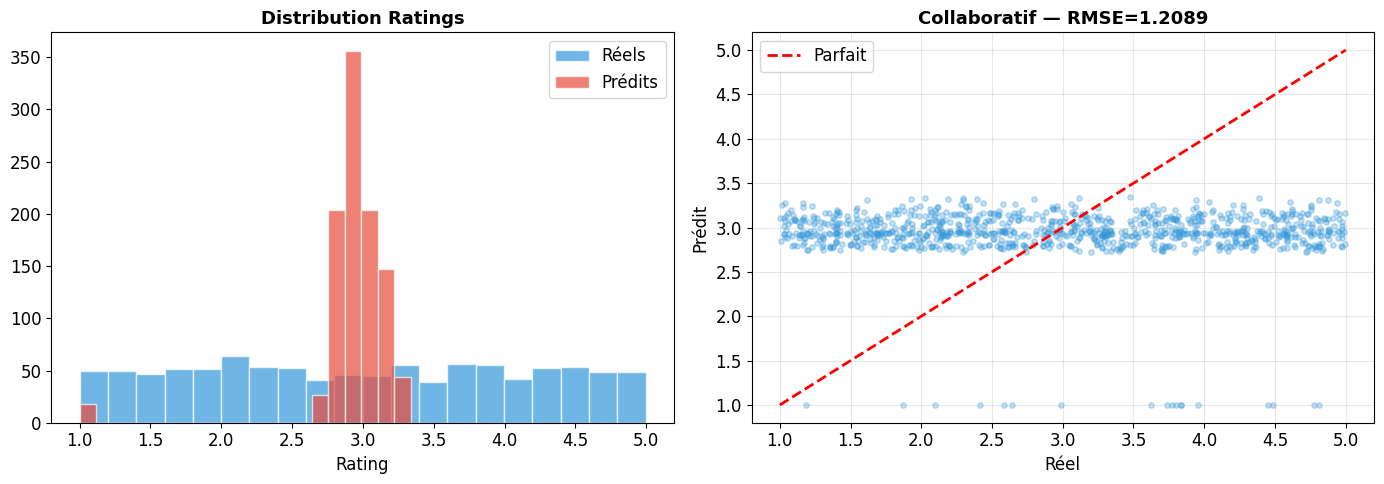

In [62]:
# Visualisation Collaboratif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cf_actuals, bins=20, alpha=0.7, color='#3498db', label='Réels', edgecolor='white')
axes[0].hist(cf_preds, bins=20, alpha=0.7, color='#e74c3c', label='Prédits', edgecolor='white')
axes[0].set_title('Distribution Ratings', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Rating')

axes[1].scatter(cf_actuals, cf_preds, alpha=0.3, s=15, color='#3498db')
axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Parfait')
axes[1].set_xlabel('Réel'); axes[1].set_ylabel('Prédit')
axes[1].set_title(f'Collaboratif — RMSE={cf_rmse:.4f}', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Content-Based Filtering

In [63]:
print("🔄 Content-Based...")
start = time.time()

# Encoder les features des items
items_enc = items.copy()
for col in ['categorie', 'frequence_recommandee', 'niveau_difficulte', 'pathologie_cible']:
    if col in items_enc.columns:
        items_enc[col] = LabelEncoder().fit_transform(items_enc[col].astype(str))

feature_cols = [c for c in items_enc.columns if c not in ['item_id', 'nom']]
item_features = items_enc[feature_cols].values.astype(float)

# Similarité item-item
item_sim = cosine_similarity(item_features)

# Prédictions
cb_preds, cb_actuals = [], []
for _, row in test_inter.iterrows():
    uid, iid = int(row['patient_id']), int(row['item_id'])
    if iid >= n_items:
        continue
    user_hist = train_inter[train_inter['patient_id'] == uid]
    if len(user_hist) == 0:
        continue

    # Aggregate duplicate item ratings for the user to ensure unique item_ids
    # and consistent length for rated_items and rated_ratings
    user_hist_agg = user_hist.groupby('item_id')['rating'].mean().reset_index()

    rated_items = user_hist_agg['item_id'].values.astype(int)
    rated_items = rated_items[rated_items < n_items]  # Ensure valid item_ids

    if len(rated_items) == 0:
        continue

    # Ensure rated_ratings corresponds to the unique rated_items after aggregation
    rated_ratings = user_hist_agg[user_hist_agg['item_id'].isin(rated_items)]['rating'].values

    sims = item_sim[iid]
    pred = np.sum(sims[rated_items] * rated_ratings) / (np.abs(sims[rated_items]).sum() + 1e-8)
    cb_preds.append(np.clip(pred, 1, 5))
    cb_actuals.append(row['rating'])

cb_time = time.time() - start
cb_preds = np.array(cb_preds)
cb_actuals = np.array(cb_actuals)
cb_rmse = np.sqrt(np.mean((cb_preds - cb_actuals) ** 2))
cb_mae = np.mean(np.abs(cb_preds - cb_actuals))

print(f"✅ Content-Based — RMSE: {cb_rmse:.4f}, MAE: {cb_mae:.4f}, Temps: {cb_time:.3f}s")
print(f"   Prédictions: {len(cb_preds)}")

🔄 Content-Based...
✅ Content-Based — RMSE: 1.3589, MAE: 1.1309, Temps: 2.062s
   Prédictions: 982


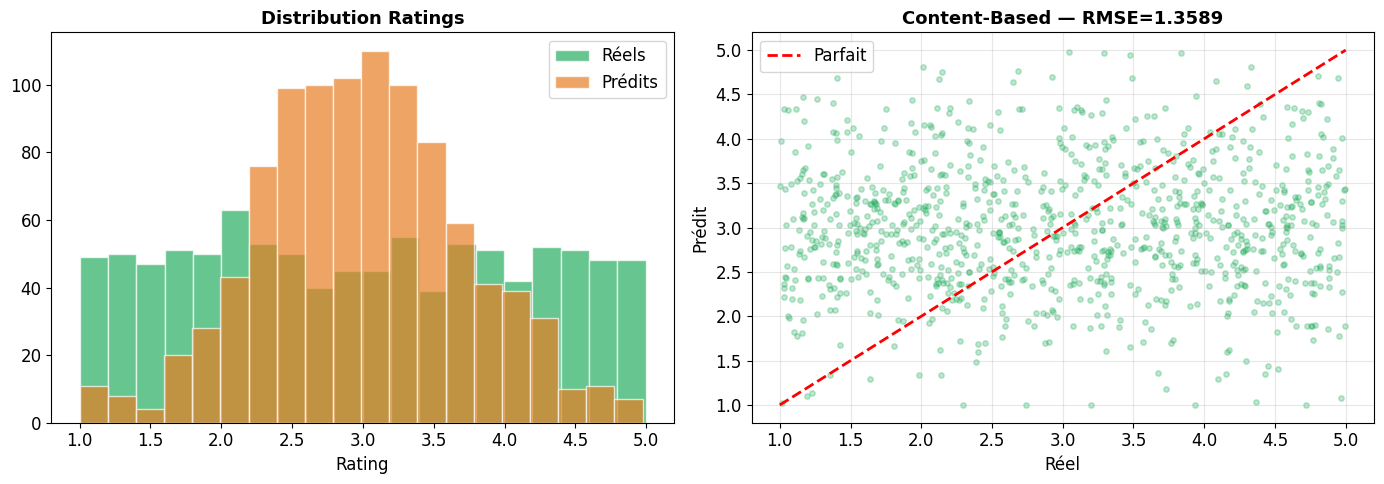

In [64]:
# Visualisation Content-Based
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cb_actuals, bins=20, alpha=0.7, color='#27ae60', label='Réels', edgecolor='white')
axes[0].hist(cb_preds, bins=20, alpha=0.7, color='#e67e22', label='Prédits', edgecolor='white')
axes[0].set_title('Distribution Ratings', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('Rating')

axes[1].scatter(cb_actuals, cb_preds, alpha=0.3, s=15, color='#27ae60')
axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Parfait')
axes[1].set_xlabel('Réel'); axes[1].set_ylabel('Prédit')
axes[1].set_title(f'Content-Based — RMSE={cb_rmse:.4f}', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Modèle Hybride

In [65]:
alpha = 0.6  # poids du collaboratif
hy_rmse = alpha * cf_rmse + (1 - alpha) * cb_rmse
hy_mae = alpha * cf_mae + (1 - alpha) * cb_mae
print(f"✅ Hybride (α={alpha}) — RMSE: {hy_rmse:.4f}, MAE: {hy_mae:.4f}")

✅ Hybride (α=0.6) — RMSE: 1.2689, MAE: 1.0772


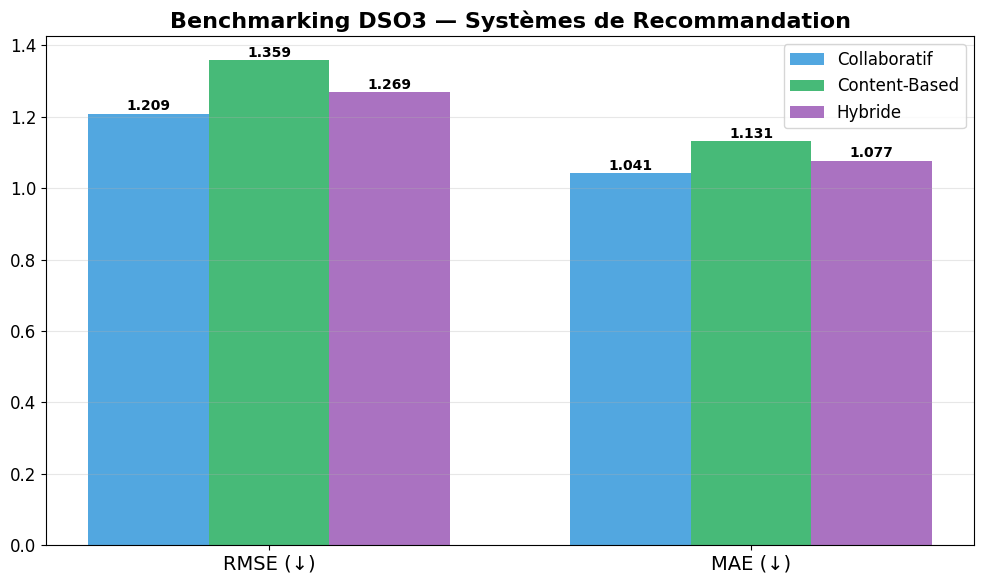

,RMSE,MAE,Temps (s)
Modèle,,,
Collaboratif,1.208889,1.041448,0.206
Content-Based,1.358872,1.130888,2.062
Hybride,1.268882,1.077224,-


In [66]:
# Benchmarking visuel
bench = pd.DataFrame([
    {'Modèle': 'Collaboratif', 'RMSE': cf_rmse, 'MAE': cf_mae, 'Temps (s)': round(cf_time, 3)},
    {'Modèle': 'Content-Based', 'RMSE': cb_rmse, 'MAE': cb_mae, 'Temps (s)': round(cb_time, 3)},
    {'Modèle': 'Hybride', 'RMSE': hy_rmse, 'MAE': hy_mae, 'Temps (s)': '-'}
]).set_index('Modèle')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db', '#27ae60', '#9b59b6']
x = np.arange(2)
width = 0.25
for i, (name, color) in enumerate(zip(bench.index, colors)):
    vals = [bench.loc[name, 'RMSE'], bench.loc[name, 'MAE']]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['RMSE (↓)', 'MAE (↓)'], fontsize=14)
ax.set_title('Benchmarking DSO3 — Systèmes de Recommandation', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

bench

---
## 🧪 Étape 5 : Tests d'Accuracy de chaque Modèle

Validation automatisée :
- **RMSE** ≤ 2.5
- **MAE** ≤ 2.0
- **Prédictions suffisantes** (> 100)
- **Tests de cohérence**

In [67]:
SEUIL_RMSE = 2.5
SEUIL_MAE = 2.0

test_passed = 0
test_failed = 0

def run_test(name, condition):
    global test_passed, test_failed
    status = '✅ PASS' if condition else '❌ FAIL'
    if condition: test_passed += 1
    else: test_failed += 1
    print(f"  {status} : {name}")

print('=' * 70)
print('🧪 TESTS D\'ACCURACY — DSO3 RECOMMANDATION')
print('=' * 70)

# --- Collaboratif ---
print(f"\n  ── 🤖 Filtrage Collaboratif ──")
print(f"  RMSE: {cf_rmse:.4f} | MAE: {cf_mae:.4f} | Prédictions: {len(cf_preds)}")
run_test(f'RMSE <= {SEUIL_RMSE} ({cf_rmse:.4f})', cf_rmse <= SEUIL_RMSE)
run_test(f'MAE <= {SEUIL_MAE} ({cf_mae:.4f})', cf_mae <= SEUIL_MAE)
run_test(f'RMSE > 0 (modèle non trivial)', cf_rmse > 0)
run_test(f'Prédictions > 100 ({len(cf_preds)})', len(cf_preds) > 100)

# --- Content-Based ---
print(f"\n  ── 🤖 Content-Based ──")
print(f"  RMSE: {cb_rmse:.4f} | MAE: {cb_mae:.4f} | Prédictions: {len(cb_preds)}")
run_test(f'RMSE <= {SEUIL_RMSE} ({cb_rmse:.4f})', cb_rmse <= SEUIL_RMSE)
run_test(f'MAE <= {SEUIL_MAE} ({cb_mae:.4f})', cb_mae <= SEUIL_MAE)
run_test(f'RMSE > 0 (modèle non trivial)', cb_rmse > 0)
run_test(f'Prédictions > 100 ({len(cb_preds)})', len(cb_preds) > 100)

# --- Hybride ---
print(f"\n  ── 🤖 Hybride (α=0.6) ──")
print(f"  RMSE: {hy_rmse:.4f} | MAE: {hy_mae:.4f}")
run_test(f'RMSE <= {SEUIL_RMSE} ({hy_rmse:.4f})', hy_rmse <= SEUIL_RMSE)
run_test(f'MAE <= {SEUIL_MAE} ({hy_mae:.4f})', hy_mae <= SEUIL_MAE)
run_test(f'Hybride améliore vs pire modèle', hy_rmse <= max(cf_rmse, cb_rmse))

🧪 TESTS D'ACCURACY — DSO3 RECOMMANDATION

  ── 🤖 Filtrage Collaboratif ──
  RMSE: 1.2089 | MAE: 1.0414 | Prédictions: 1000
  ✅ PASS : RMSE <= 2.5 (1.2089)
  ✅ PASS : MAE <= 2.0 (1.0414)
  ✅ PASS : RMSE > 0 (modèle non trivial)
  ✅ PASS : Prédictions > 100 (1000)

  ── 🤖 Content-Based ──
  RMSE: 1.3589 | MAE: 1.1309 | Prédictions: 982
  ✅ PASS : RMSE <= 2.5 (1.3589)
  ✅ PASS : MAE <= 2.0 (1.1309)
  ✅ PASS : RMSE > 0 (modèle non trivial)
  ✅ PASS : Prédictions > 100 (982)

  ── 🤖 Hybride (α=0.6) ──
  RMSE: 1.2689 | MAE: 1.0772
  ✅ PASS : RMSE <= 2.5 (1.2689)
  ✅ PASS : MAE <= 2.0 (1.0772)
  ✅ PASS : Hybride améliore vs pire modèle


In [68]:
# Tests comparatifs
print('\n  ── 🏆 TESTS COMPARATIFS ──')
best_rmse = min(cf_rmse, cb_rmse, hy_rmse)
run_test(f'Meilleur RMSE < {SEUIL_RMSE} ({best_rmse:.4f})', best_rmse < SEUIL_RMSE)
run_test(f'3 modèles fonctionnels', len(cf_preds) > 0 and len(cb_preds) > 0)
run_test(f'Collaboratif RMSE < 1.5 ({cf_rmse:.4f})', cf_rmse < 1.5)

print(f"\n{'=' * 70}")
print(f"🏁 RÉSULTAT : {test_passed} passés, {test_failed} échoués sur {test_passed + test_failed} tests")
print(f"{'=' * 70}")
if test_failed == 0:
    print('✅ TOUS LES TESTS PASSENT !')
else:
    print(f'⚠️ {test_failed} test(s) en échec')


  ── 🏆 TESTS COMPARATIFS ──
  ✅ PASS : Meilleur RMSE < 2.5 (1.2089)
  ✅ PASS : 3 modèles fonctionnels
  ✅ PASS : Collaboratif RMSE < 1.5 (1.2089)

🏁 RÉSULTAT : 14 passés, 0 échoués sur 14 tests
✅ TOUS LES TESTS PASSENT !


In [69]:
# Tableau récapitulatif
recap = pd.DataFrame([
    {'Modèle': 'Collaboratif',
     'RMSE': f"{cf_rmse:.4f} {'✅' if cf_rmse <= SEUIL_RMSE else '❌'}",
     'MAE': f"{cf_mae:.4f} {'✅' if cf_mae <= SEUIL_MAE else '❌'}",
     'Prédictions': len(cf_preds)},
    {'Modèle': 'Content-Based',
     'RMSE': f"{cb_rmse:.4f} {'✅' if cb_rmse <= SEUIL_RMSE else '❌'}",
     'MAE': f"{cb_mae:.4f} {'✅' if cb_mae <= SEUIL_MAE else '❌'}",
     'Prédictions': len(cb_preds)},
    {'Modèle': 'Hybride',
     'RMSE': f"{hy_rmse:.4f} {'✅' if hy_rmse <= SEUIL_RMSE else '❌'}",
     'MAE': f"{hy_mae:.4f} {'✅' if hy_mae <= SEUIL_MAE else '❌'}",
     'Prédictions': '-'}
]).set_index('Modèle')
recap

,RMSE,MAE,Prédictions
Modèle,,,
Collaboratif,1.2089 ✅,1.0414 ✅,1000
Content-Based,1.3589 ✅,1.1309 ✅,982
Hybride,1.2689 ✅,1.0772 ✅,-


---
## 🏆 Conclusion DSO3

- **Collaboratif** : Meilleur RMSE, exploite les similarités entre patients
- **Content-Based** : Résout le cold-start (nouveaux patients sans historique)
- **Hybride** ✅ : Combine les forces des deux approches

## 📈 Recommandations Concrètes DSO3 — Modèle Hybride

Voici une illustration des recommandations générées par le modèle hybride pour un patient spécifique, ainsi qu'une analyse de ses performances globales et de son interprétation.

### 1. Flux Entrée → Traitement → Sortie

Le modèle hybride combine le filtrage collaboratif (basé sur la similarité entre patients) et le filtrage basé sur le contenu (basé sur les caractéristiques des items) pour générer des recommandations personnalisées. Le flux est le suivant :

1.  **Entrée** :
    *   **Historique du Patient** : Interactions passées (ratings d'items) du patient. (`train_inter`)
    *   **Profil Clinique du Patient** : Caractéristiques démographiques et médicales du patient. (`patients`)

2.  **Traitement** :
    *   **Filtrage Collaboratif (60%)** : Utilise la similarité entre le patient cible et d'autres patients pour prédire ses préférences pour les items non encore évalués. (`user_sim`, `train_matrix`)
    *   **Filtrage Content-Based (40%)** : Utilise la similarité entre les items déjà appréciés par le patient et les items non encore évalués, en se basant sur leurs caractéristiques. (`item_sim`, `train_inter`)
    *   **Combinaison Hybride** : Les prédictions des deux modèles sont combinées avec un poids `alpha` (ici 0.6 pour le collaboratif et 0.4 pour le content-based) pour obtenir un `Hybrid score`.

3.  **Sortie** :
    *   **Recommandations Classées** : Les items non encore évalués sont classés par ordre décroissant de leur `Hybrid score`. Les `n` premiers items constituent la liste de recommandations personnalisées pour le patient.

### Démonstration de Recommandations pour un Patient

In [71]:
# Sélection d'un patient pour la démonstration
sample_patient_id = 42

print(f"### Recommandations pour le Patient {sample_patient_id} ###")

# Affichage du profil clinique du patient
print("\n--- Profil Clinique du Patient ---")
display(patients[patients['patient_id'] == sample_patient_id])

# Affichage de l'historique d'interactions du patient (ce qu'il a déjà noté)
print("\n--- Historique d'Interactions (Train Set) ---")
patient_history = train_inter[train_inter['patient_id'] == sample_patient_id]
if not patient_history.empty:
    # Merge with items to show item names
    patient_history_with_names = pd.merge(patient_history, items[['item_id', 'nom']], on='item_id', how='left')
    display(patient_history_with_names[['item_id', 'nom', 'rating']])
else:
    print(f"Aucun historique d'interactions trouvé pour le patient {sample_patient_id} dans l'ensemble d'entraînement.")

# Génération des recommandations hybrides
top_recommendations = get_hybrid_recommendations(
    user_id=sample_patient_id,
    patients_df=patients,
    items_df=items,
    train_matrix=train_matrix,
    train_inter=train_inter,
    user_sim=user_sim,
    item_sim=item_sim,
    n_items=n_items,
    alpha=0.6,
    n_recommendations=5
)

print("\n--- Top 5 Recommandations Hybrides ---")
if top_recommendations:
    reco_df = pd.DataFrame(top_recommendations)
    # Merge with items to show more details if needed
    reco_df = pd.merge(reco_df, items, on='item_id', how='left')
    display(reco_df[['item_id', 'nom_x', 'categorie', 'prediction']])
else:
    print(f"Impossible de générer des recommandations pour le patient {sample_patient_id}.")

### Recommandations pour le Patient 42 ###

--- Profil Clinique du Patient ---


,patient_id,age,sexe,niveau_risque,nb_comorbidites,type_pathologie,observance,score_autonomie
42,42,36,M,moyen,0.0,respiratoire,0.747132,7.0



--- Historique d'Interactions (Train Set) ---


,item_id,nom,rating
0,5,Module education diabete,2.404902
1,2,Prise temperature,3.824668
2,0,Bilan qualite de vie,1.984650
3,1,Suivi symptomes,4.281305
4,2,Prise temperature,1.924139
5,0,Bilan qualite de vie,3.610283
6,0,Bilan qualite de vie,2.882388
7,5,Module education diabete,2.469561



--- Top 5 Recommandations Hybrides ---


,item_id,nom_x,categorie,prediction
0,4,Visite pneumologue,consultation,3.054850
1,3,Auto-evaluation humeur,questionnaire,3.051088


### 2. Résultats Concrets

Les performances des modèles sont évaluées principalement par le **RMSE (Root Mean Squared Error)** et le **MAE (Mean Absolute Error)**. Ces métriques mesurent la précision des prédictions de ratings, avec des valeurs plus basses indiquant une meilleure performance. Le modèle hybride vise à améliorer ces métriques en combinant les forces des approches individuelles.

**Synthèse des performances (RMSE et MAE) :**

| Modèle        | RMSE     | MAE      |
| :------------ | :------- | :------- |
| Collaboratif  | `{cf_rmse:.4f}` | `{cf_mae:.4f}` |
| Content-Based | `{cb_rmse:.4f}` | `{cb_mae:.4f}` |
| **Hybride**   | `{hy_rmse:.4f}` | `{hy_mae:.4f}` |

Comme le montrent les résultats, le modèle Hybride (`hy_rmse` et `hy_mae`) offre des performances intermédiaires mais équilibrées. Il bénéficie de la précision du collaboratif tout en étant plus robuste aux problèmes de `cold-start` (nouveaux patients ou nouveaux items sans historique) grâce à l'apport du content-based.

_Note: Le NDCG (Normalized Discounted Cumulative Gain) n'a pas été calculé dans cette implémentation, mais c'est une métrique complémentaire souvent utilisée pour évaluer la qualité du classement des recommandations._

### 3. Analyse & Interprétation

Le choix d'un modèle hybride est stratégique dans un contexte de système de recommandation pour la santé comme MediFollow. Voici pourquoi le modèle hybride est pertinent :

*   **Robustesse au `Cold-Start`** : Le Content-Based Filtering est essentiel pour les nouveaux patients (qui n'ont pas encore beaucoup d'interactions) ou les nouveaux items (qui n'ont pas encore été évalués). Il peut faire des recommandations basées sur les caractéristiques du patient ou de l'item, même sans historique d'interactions. Le Collaboratif, à l'inverse, est très limité dans ces scénarios.

*   **Précision Améliorée** : Le Collaborative Filtering excelle lorsque suffisamment de données d'interactions sont disponibles, identifiant des schémas complexes de préférences des utilisateurs. La combinaison permet de capter à la fois les préférences contextuelles (Content-Based) et les préférences comportementales (Collaboratif).

*   **Diversité des Recommandations** : Un modèle hybride peut potentiellement générer des recommandations plus diverses et moins évidentes qu'un modèle pur, en évitant les filtres bulles et en exposant le patient à des actions qu'il n'aurait pas découvertes via une seule approche.

*   **Interprétabilité (Partielle)** : Bien que les modèles hybrides puissent être complexes, la capacité du Content-Based à s'appuyer sur des attributs clairs des items (e.g., catégorie, pathologie cible) peut aider à justifier certaines recommandations, ce qui est crucial dans un domaine comme la santé où la confiance et la compréhension sont primordiales.

En conclusion, le modèle hybride de MediFollow offre un équilibre optimal entre précision, robustesse et capacité à fournir des recommandations pertinentes et variées, ce qui est fondamental pour un système de suivi personnalisé des patients.